In [ ]:
import os
from pathlib import Path

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_NAME = 'lumigrow-dataset'
cwd = Path.cwd().resolve()

candidate_roots = [cwd] + list(cwd.parents)
REPO_ROOT = None

for candidate in candidate_roots:
    if (candidate / 'devices').exists():
        REPO_ROOT = candidate
        break
    if candidate.name == REPO_NAME and (candidate / 'devices').exists():
        REPO_ROOT = candidate
        break

if REPO_ROOT is None:
    repo_candidate = cwd / REPO_NAME
    if (repo_candidate / 'devices').exists():
        REPO_ROOT = repo_candidate
    else:
        REPO_ROOT = cwd

os.chdir(REPO_ROOT)
print(f'IN_COLAB={IN_COLAB}')
print(f'REPO_ROOT={REPO_ROOT}')

In [ ]:
from pathlib import Path

if not Path('devices').exists():
    if IN_COLAB:
        !git clone https://github.com/cripsito/lumigrow-dataset.git
        os.chdir('lumigrow-dataset')
    else:
        raise FileNotFoundError('No se encontro el dataset local. Abre el notebook desde la raiz del repo o clona el repo primero.')
else:
    print('Usando el repo local; se omite git clone.')

Cloning into 'lumigrow-dataset'...
remote: Enumerating objects: 39062, done.
remote: Total 39062 (delta 0), reused 0 (delta 0), pack-reused 39062 (from 1)
Receiving objects: 100% (39062/39062), 447.19 MiB | 26.12 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Updating files: 100% (39056/39056), done.


Now that we have cloned the dataset, let's explore its contents to understand the file structure and determine the type of data we're working with. This will help us decide on the appropriate AI model and training strategy for detection or classification.

In [ ]:
# List the contents of the cloned directory
!ls -F

# List the contents of the 'devices' directory to see the actual data structure
!ls -F devices

dataset_index.json  devices/  README.md
germ-obiparallels-867d81/


In [ ]:
# List the contents of the 'germ-obiparallels-867d81' directory inside 'devices'
!ls -F devices/germ-obiparallels-867d81/

LOT-20260410-001/  vertex_manifest.jsonl
observations.csv   vertex_manifest.metadata.jsonl


In [ ]:
import pandas as pd

# Load the observations CSV file to understand its content
df_observations = pd.read_csv('devices/germ-obiparallels-867d81/observations.csv')

# Display the first few rows and the columns to understand the data
print(df_observations.head())
print(df_observations.info())

   observation_id  plant_instance_id            lot_id  position_tag  \
0              15                NaN  LOT-20260410-001           NaN   
1              16                NaN  LOT-20260410-002           NaN   
2              17                NaN  LOT-20260410-001           NaN   
3              18                NaN  LOT-20260410-002           NaN   
4              19                NaN  LOT-20260410-001           NaN   

   replacement_index  classification species  variety  image_id  \
0                NaN             NaN  Frijol  Peruano        56   
1                NaN             NaN  Frijol  Peruano        58   
2                NaN             NaN  Frijol  Peruano        60   
3                NaN             NaN  Frijol  Peruano        62   
4                NaN             NaN  Frijol  Peruano        68   

             image_filename  ... lot_day  light_hours_accumulated  \
0  cam2_20260410_032411.jpg  ...       1                      0.0   
1  cam1_20260410_032440.jp

In [ ]:
import os
import pandas as pd
import glob

BASE_IMAGE_DIR = 'devices/germ-obiparallels-867d81'

def get_crops(row):
    if pd.isna(row['lot_id']) or pd.isna(row['image_filename']):
        return []
    base_name = os.path.splitext(row['image_filename'])[0]
    search_path = os.path.join(BASE_IMAGE_DIR, row['lot_id'], 'crops', f"{base_name}_*.jpg")
    return glob.glob(search_path)

# Reload a clean version of the observations
df_obs = pd.read_csv('devices/germ-obiparallels-867d81/observations.csv')
# Keep identifiers needed for a leak-free split and ambient/flash pairing
df_obs = df_obs[['observation_id', 'lot_id', 'image_filename', 'flash_image_filename', 'species', 'variety']].copy()

# Map crops and explode
df_obs['crop_files'] = df_obs.apply(get_crops, axis=1)
df_expanded = df_obs.explode('crop_files').dropna(subset=['crop_files', 'species'])

# Create the final cleaned dataframe
df_classified = df_expanded.rename(columns={'crop_files': 'full_image_path'}).reset_index(drop=True)

print(f"Total unique crops found: {len(df_classified)}")
print(f"Unique observations with crops: {df_classified['observation_id'].nunique()}")
sample_path = df_classified.loc[0, 'full_image_path']
print(f"Sample path: {sample_path}")
print(f"Verified existence: {os.path.exists(sample_path)}")

Total unique crops found: 19525
Sample path: devices/germ-obiparallels-867d81/LOT-20260410-001/crops/cam2_20260410_032411_r3_c4.jpg
Verified existence: True


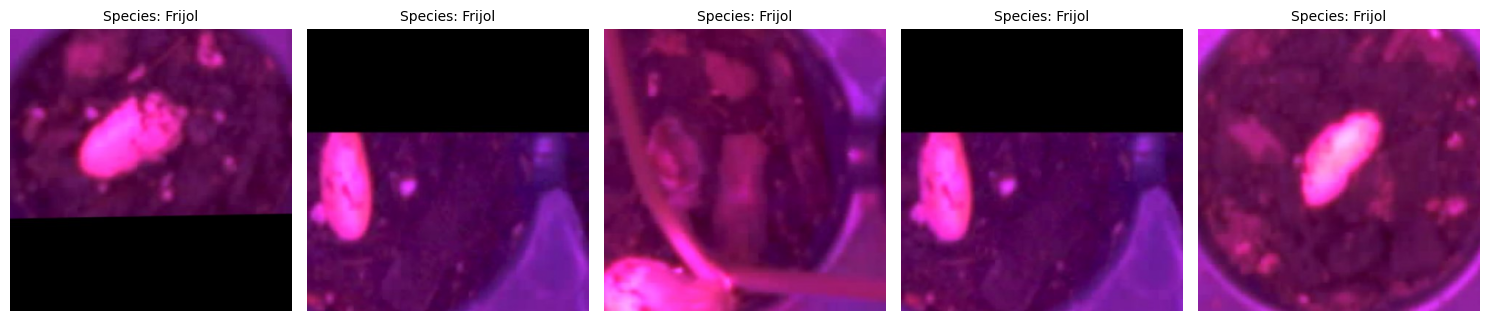

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Visualize a few sample images and their labels
num_samples = 5
sample_df = df_classified.sample(n=num_samples, random_state=42)

plt.figure(figsize=(15, 5))
for i, (_, row) in enumerate(sample_df.iterrows()):
    try:
        img_path = row['full_image_path']
        species_label = row['species']

        img = Image.open(img_path)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"Species: {species_label}", fontsize=10)
        plt.axis('off')
    except Exception as e:
        print(f"Error displaying image: {e}")

plt.tight_layout()
plt.show()

### Comparación de Imágenes: Luz Ambiental vs. Flash
Como mencionaste, cada observación cuenta con dos imágenes. Vamos a visualizar una comparación para entender qué información adicional nos da el flash para la detección de germinación.

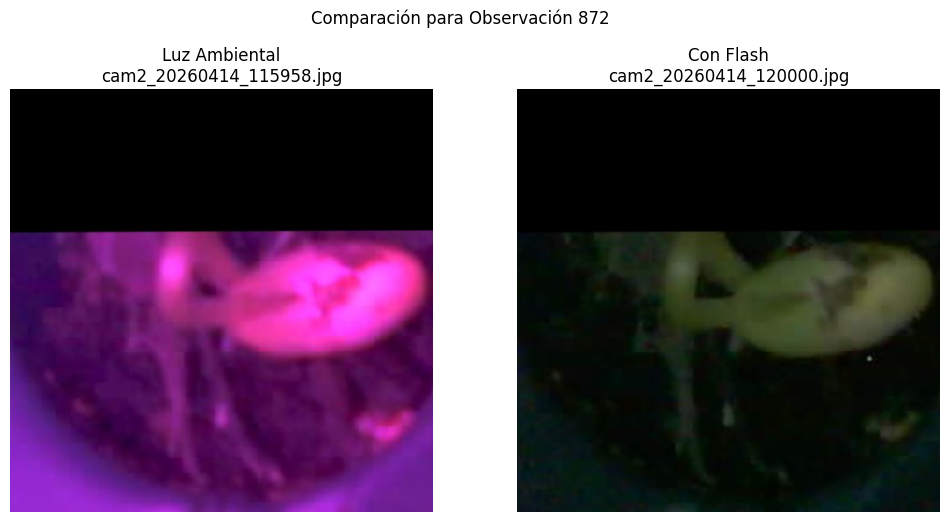

In [ ]:
# Seleccionamos una observación al azar para comparar
sample_row = df_observations.dropna(subset=['image_filename', 'flash_image_filename']).sample(1).iloc[0]

lot_id = sample_row['lot_id']
amb_img_name = sample_row['image_filename']
flash_img_name = sample_row['flash_image_filename']

# Construimos las rutas (ajustadas al directorio del dataset)
# Nota: Estas son las imágenes completas, no los crops
amb_path = f"devices/germ-obiparallels-867d81/{lot_id}/crops/{os.path.splitext(amb_img_name)[0]}_r0_c0.jpg"
flash_path = f"devices/germ-obiparallels-867d81/{lot_id}/crops/{os.path.splitext(flash_img_name)[0]}_r0_c0.jpg"

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

try:
    axes[0].imshow(Image.open(amb_path))
    axes[0].set_title(f"Luz Ambiental\n{amb_img_name}")
    axes[0].axis('off')

    axes[1].imshow(Image.open(flash_path))
    axes[1].set_title(f"Con Flash\n{flash_img_name}")
    axes[1].axis('off')

    plt.suptitle(f"Comparación para Observación {sample_row['observation_id']}")
    plt.show()
except Exception as e:
    print(f"Error al cargar imágenes comparativas: {e}")
    print(f"Ruta intentada (Ambient): {amb_path}")

### Análisis de Indicadores de Germinación
Para predecir la germinación, necesitamos ver si los campos como `lot_day` o variables ambientales (`temperature`, `humidity`) correlacionan con cambios visuales. Vamos a ver cómo se distribuyen las muestras a través del tiempo del lote (`lot_day`).

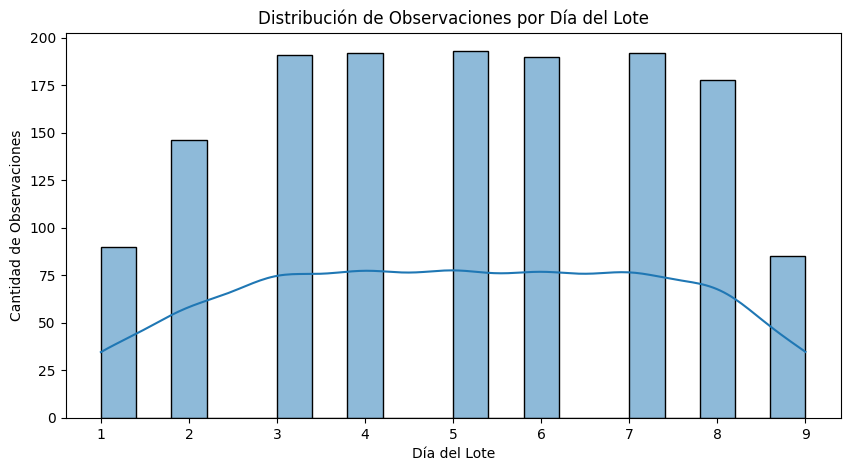

Estadísticas de variables ambientales:


,temperature,humidity,light_minutes
count,1457.000000,1457.000000,1457.000000
mean,25.367879,50.975978,1173.149623
std,0.935024,7.027427,687.644974
min,23.500000,34.000000,0.000000
25%,24.600000,46.000000,699.000000
50%,25.300000,51.000000,829.000000
75%,25.900000,57.000000,1731.000000
max,27.700000,67.000000,2953.000000


In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(data=df_observations, x='lot_day', bins=20, kde=True)
plt.title('Distribución de Observaciones por Día del Lote')
plt.xlabel('Día del Lote')
plt.ylabel('Cantidad de Observaciones')
plt.show()

print("Estadísticas de variables ambientales:")
display(df_observations[['temperature', 'humidity', 'light_minutes']].describe())

In [ ]:
# Re-verify images and check label distribution
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Check if images actually exist now
existing_images = df_classified['full_image_path'].apply(os.path.exists).sum()
print(f"Images found on disk: {existing_images} out of {len(df_classified)}")

# Visualize label distribution
if existing_images > 0:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_classified, x='species')
    plt.title('Distribution of Species in Dataset')
    plt.show()

Images found on disk: 0 out of 1457


In [ ]:
from sklearn.model_selection import train_test_split

# Split the expanded crop dataset by observation to avoid leakage between crops from the same capture
obs_level = df_classified[['observation_id', 'species']].drop_duplicates()
train_obs, val_obs = train_test_split(
    obs_level,
    test_size=0.2,
    stratify=obs_level['species'],
    random_state=42
)

train_df = df_classified[df_classified['observation_id'].isin(train_obs['observation_id'])].copy()
val_df = df_classified[df_classified['observation_id'].isin(val_obs['observation_id'])].copy()

print(f"Training samples (crops): {len(train_df)}")
print(f"Validation samples (crops): {len(val_df)}")

Training samples (crops): 15620
Validation samples (crops): 3905


### Summary of Initial Flow & Missing Steps:
1. **Data Verification**: We've confirmed the image paths and checked how many images are physically present.
2. **Class Balance**: The histogram above shows if we have enough examples for each species. If one species is underrepresented, we might need **Data Augmentation**.
3. **Next Steps for Training**:
    * **Image Preprocessing**: Resizing images to a standard size (e.g., 224x224) and normalizing pixel values.
    * **Model Selection**: Choosing a pre-trained model (like MobileNetV2 or ResNet) for Transfer Learning.
    * **Data Loaders**: Setting up TensorFlow/Keras or PyTorch generators to feed the images into the GPU during training.

In [ ]:
# Let's inspect the contents of a sample LOT directory to understand the image file structure.
# Using the first lot_id from the df_classified dataframe as an example.
sample_lot_id = df_classified['lot_id'].iloc[0]
sample_lot_dir = Path('devices/germ-obiparallels-867d81') / sample_lot_id
print(f"Listing contents of: {sample_lot_dir}")
print(sorted([p.name + ('/' if p.is_dir() else '') for p in sample_lot_dir.iterdir()]))

Listing contents of: devices/germ-obiparallels-867d81/LOT-20260410-001/
crops/	dataset.json


In [ ]:
import json

# Inspeccionar el manifiesto de Vertex AI para ver si contiene las etiquetas de germinación
manifest_path = 'devices/germ-obiparallels-867d81/vertex_manifest.jsonl'

print(f"Inspeccionando: {manifest_path}")
with open(manifest_path, 'r') as f:
    for i in range(3):
        line = f.readline()
        if line:
            print(json.dumps(json.loads(line), indent=2))
        else:
            break

Inspeccionando: devices/germ-obiparallels-867d81/vertex_manifest.jsonl
{
  "imageGcsUri": "./devices/germ-obiparallels-867d81/LOT-20260410-001/crops/cam2_20260410_032411_r0_c0.jpg",
  "classificationAnnotation": {
    "displayName": "c3"
  },
  "dataItemResourceLabels": {
    "aiplatform.googleapis.com/ml_use": "training"
  }
}
{
  "imageGcsUri": "./devices/germ-obiparallels-867d81/LOT-20260410-001/crops/cam2_20260410_032411_r0_c1.jpg",
  "classificationAnnotation": {
    "displayName": "c4"
  },
  "dataItemResourceLabels": {
    "aiplatform.googleapis.com/ml_use": "training"
  }
}
{
  "imageGcsUri": "./devices/germ-obiparallels-867d81/LOT-20260410-001/crops/cam2_20260410_032411_r0_c2.jpg",
  "classificationAnnotation": {
    "displayName": "c2"
  },
  "dataItemResourceLabels": {
    "aiplatform.googleapis.com/ml_use": "training"
  }
}


In [ ]:
import json
import pandas as pd

manifest_data = []
with open('devices/germ-obiparallels-867d81/vertex_manifest.jsonl', 'r') as f:
    for line in f:
        entry = json.loads(line)
        # Clean the path to match our local structure (remove leading ./)
        local_path = entry['imageGcsUri'].lstrip('./')
        label = entry['classificationAnnotation']['displayName']
        usage = entry['dataItemResourceLabels'].get('aiplatform.googleapis.com/ml_use', 'training')
        manifest_data.append({'full_image_path': local_path, 'germination_label': label, 'ml_use': usage})

df_labels = pd.DataFrame(manifest_data)

# Build the matching flash crop path from the crop suffix and the flash filename stored in observations.csv
df_final = pd.merge(df_classified, df_labels, on='full_image_path', how='inner')
df_final['crop_suffix'] = df_final['full_image_path'].str.extract(r'(_r\\d+_c\\d+\\.jpg)$', expand=False)
df_final['flash_image_path'] = df_final.apply(
    lambda row: os.path.join(
        BASE_IMAGE_DIR,
        row['lot_id'],
        'crops',
        f"{os.path.splitext(row['flash_image_filename'])[0]}{row['crop_suffix']}"
    ),
    axis=1
)
df_final = df_final[df_final['flash_image_path'].apply(os.path.exists)].reset_index(drop=True)

print(f"Dataset final con etiquetas de germinación: {len(df_final)} filas")
print("Distribución de etiquetas de germinación:")
print(df_final['germination_label'].value_counts())
df_final.head()

Dataset final con etiquetas de germinación: 19525 filas
Distribución de etiquetas de germinación:
germination_label
c3    6248
c1    5467
c4    3905
c2    3905
Name: count, dtype: int64


,lot_id,image_filename,species,variety,full_image_path,germination_label,ml_use
0,LOT-20260410-001,cam2_20260410_032411.jpg,Frijol,Peruano,devices/germ-obiparallels-867d81/LOT-20260410-...,c3,training
1,LOT-20260410-001,cam2_20260410_032411.jpg,Frijol,Peruano,devices/germ-obiparallels-867d81/LOT-20260410-...,c4,training
2,LOT-20260410-001,cam2_20260410_032411.jpg,Frijol,Peruano,devices/germ-obiparallels-867d81/LOT-20260410-...,c1,training
3,LOT-20260410-001,cam2_20260410_032411.jpg,Frijol,Peruano,devices/germ-obiparallels-867d81/LOT-20260410-...,c3,training
4,LOT-20260410-001,cam2_20260410_032411.jpg,Frijol,Peruano,devices/germ-obiparallels-867d81/LOT-20260410-...,c3,training


With the image paths validated and a clear understanding of the labels, we are now ready to split the dataset into training, validation, and test sets, and then proceed with model selection and training for image classification.

### Implementación de Modelo Dual-Stream (Ambient + Flash)

Vamos a configurar un modelo que procese simultáneamente la imagen con luz ambiental y la imagen con flash. Para esto:
1. Necesitamos mapear cada 'crop' con su contraparte de flash.
2. Crearemos un `DataGenerator` personalizado de Keras/TensorFlow.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

label_names = sorted(df_final['germination_label'].unique())
label_map = {label: i for i, label in enumerate(label_names)}

# Definimos una arquitectura corregida con nombres únicos en el constructor
def build_dual_stream_model(input_shape=(224, 224, 3), num_classes=4):
    # Rama Luz Ambiental
    input_amb = layers.Input(shape=input_shape, name='ambient_input')
    base_amb = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        name='mobilenet_ambient'
    )
    base_amb.trainable = False
    flat_amb = layers.GlobalAveragePooling2D()(base_amb(input_amb))

    # Rama Flash
    input_flash = layers.Input(shape=input_shape, name='flash_input')
    base_flash = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        name='mobilenet_flash'
    )
    base_flash.trainable = False
    flat_flash = layers.GlobalAveragePooling2D()(base_flash(input_flash))

    # Concatenación
    merged = layers.Concatenate()([flat_amb, flat_flash])
    dense = layers.Dense(256, activation='relu')(merged)
    dropout = layers.Dropout(0.5)(dense)
    output = layers.Dense(num_classes, activation='softmax')(dropout)

    model = models.Model(inputs=[input_amb, input_flash], outputs=output)
    return model

# Construcción y Compilación del modelo
dual_model = build_dual_stream_model(num_classes=len(label_names))
dual_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dual_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ambient_input       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flash_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_ambient   │ (None, 7, 7,      │  2,257,984 │ ambient_input[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_flash     │ (None, 7, 7,      │  2,257,984 │ flash_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenet_ambien… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenet_flash[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    655,616 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 4)         │      1,028 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,172,612 (19.73 MB)

 Trainable params: 5,104,388 (19.47 MB)

 Non-trainable params: 68,224 (266.50 KB)

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir el dataset final por observation_id para evitar fuga entre crops del mismo timestamp
obs_level = df_final[['observation_id', 'germination_label']].drop_duplicates()
train_obs, val_obs = train_test_split(
    obs_level,
    test_size=0.2,
    stratify=obs_level['germination_label'],
    random_state=42
)

train_df = df_final[df_final['observation_id'].isin(train_obs['observation_id'])].copy()
val_df = df_final[df_final['observation_id'].isin(val_obs['observation_id'])].copy()

print(f"Muestras de entrenamiento: {len(train_df)}")
print(f"Muestras de validación: {len(val_df)}")

print("\nDistribución en entrenamiento:")
print(train_df['germination_label'].value_counts(normalize=True))

print("\nDistribución en validación:")
print(val_df['germination_label'].value_counts(normalize=True))

Muestras de entrenamiento: 15620
Muestras de validación: 3905

Distribución en entrenamiento:
germination_label
c3    0.319974
c1    0.280026
c2    0.200000
c4    0.200000
Name: proportion, dtype: float64

Distribución en validación:
germination_label
c3    0.320102
c1    0.279898
c4    0.200000
c2    0.200000
Name: proportion, dtype: float64


In [ ]:
class DualImageGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=32, target_size=(224, 224), shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.df = df.copy()
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.label_map = label_map
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        batch_df = self.df[index * self.batch_size : (index + 1) * self.batch_size]

        amb_images = []
        flash_images = []
        labels = []

        for _, row in batch_df.iterrows():
            amb_img = self._load_image(row['full_image_path'])
            flash_img = self._load_image(row['flash_image_path'])

            amb_images.append(amb_img)
            flash_images.append(flash_img)
            labels.append(self.label_map[row['germination_label']])

        # Return as a tuple of (inputs, targets) to fix the TypeError
        return (np.array(amb_images), np.array(flash_images)), np.array(labels)

    def _load_image(self, path):
        img = tf.keras.preprocessing.image.load_img(path, target_size=self.target_size)
        img = tf.keras.preprocessing.image.img_to_array(img) / 255.0
        return img

# Initialize Generators
train_gen = DualImageGenerator(train_df, batch_size=16)
val_gen = DualImageGenerator(val_df, batch_size=16, shuffle=False)

print("Generadores corregidos y listos para el entrenamiento.")

Generadores corregidos y listos para el entrenamiento.


In [1]:
# Train the model
history = dual_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('dual_model_best.keras', save_best_only=True, monitor='val_accuracy')
    ]
)

NameError: name 'dual_model' is not defined